# Week 2: Descriptive Analytics

## Objective

This notebook performs descriptive analysis on the cleaned Job Bank dataset to understand labour market trends across Canada.

The analysis includes:

- Total job postings
- Total advertised vacancies
- Number of employers
- Number of occupations
- Provincial demand distribution
- Employment type distribution
- Education requirement
- Experience requirement
- Top occupations by demand

In [2]:
# Import required libraries for descriptive analytics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# Define project paths

PROJECT_ROOT = Path(
    r"C:\Users\Admin\Capstone_Project"
)

CLEAN_FILE = (
    PROJECT_ROOT /
    "Data" /
    "Processed" /
    "job_bank_preliminary_clean.csv"
)

TABLES = PROJECT_ROOT / "Outputs" / "Tables"
FIGURES = PROJECT_ROOT / "Outputs" / "Figures"

# Create output folders if they do not exist

TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

In [6]:
# Load preliminary cleaned Job Bank dataset

job_bank_clean = pd.read_csv(
    CLEAN_FILE,
    low_memory=False
)

print(
    f"Dataset loaded: "
    f"{job_bank_clean.shape[0]:,} rows × "
    f"{job_bank_clean.shape[1]} columns"
)

Dataset loaded: 55,091 rows × 66 columns


In [8]:
# Preview the cleaned Job Bank dataset

job_bank_clean.head()

,posting_id,job_title,original_job_title,noc_2016_code,noc_2016_name,noc_2021_code,noc_2021_name,external_indicator,posting_date,vacancy_count,...,salary_condition_other_benefits,commission_per,commission_type,hours_per,hours_minimum,hours_maximum,work_hours,work_hours_from_time,work_hours_to_time,salary_average
0,15645194,Facilities and Fleet Maintenance Support,NaN,NaN,NaN,NaN,NaN,1,2026-06-17,1,...,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,29.20
1,15675531,sales associate,Part Time Sales Associate-SoftMoc ShoeRack Cro...,6421.0,Retail salespersons,64100.0,Retail salespersons and visual merchandisers,1,2026-06-29,1,...,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,16.25
2,15597307,"testing, adjusting and balancing (tab) technic...",HVAC R & Gasfitter Journeymen Apprentice (Leve...,2232.0,Mechanical engineering technologists and techn...,11201.0,Professional occupations in business managemen...,1,2026-06-01,1,...,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,50.00
3,15621351,"chartered professional accountant, chartered a...",NaN,1111.0,Financial auditors and accountants,11100.0,Financial auditors and accountants,0,2026-06-09,1,...,No,NaN,NaN,Week,4.0,10.0,No,NaN,NaN,65.00
4,15629538,refrigeration technician,NaN,7313.0,Refrigeration and air conditioning mechanics,72402.0,"Heating, refrigeration and air conditioning me...",1,2026-06-11,1,...,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,41.50


In [10]:
# Calculate total number of job postings

total_postings = len(job_bank_clean)

print(
    "Total Number of Job Postings:",
    f"{total_postings:,}"
)

Total Number of Job Postings: 55,091


In [12]:
# Calculate total advertised vacancies

total_vacancies = job_bank_clean[
    "vacancy_count"
].sum()

print(
    "Total Advertised Vacancies:",
    f"{total_vacancies:,.0f}"
)

Total Advertised Vacancies: 89,058


In [14]:
# Calculate number of unique occupations using NOC 2021 classification

number_of_occupations = (
    job_bank_clean[
        "noc_2021_code"
    ]
    .nunique()
)

print(
    "Number of Unique NOC 2021 Occupations:",
    number_of_occupations
)

Number of Unique NOC 2021 Occupations: 500


In [16]:
# Calculate number of unique occupation names using NOC 2021 classification

number_of_occupation_names = (
    job_bank_clean["noc_2021_name"]
    .nunique()
)

print(
    "Number of Unique NOC 2021 Occupation Names:",
    number_of_occupation_names
)

Number of Unique NOC 2021 Occupation Names: 500


In [18]:
# Calculate number of provinces and territories represented

number_of_provinces = (
    job_bank_clean[
        "province"
    ]
    .nunique()
)

print(
    "Number of Provinces/Territories:",
    number_of_provinces
)

Number of Provinces/Territories: 13


In [20]:
# Calculate median vacancies per job posting

median_vacancies = (
    job_bank_clean[
        "vacancy_count"
    ]
    .median()
)

print(
    "Median Vacancies per Posting:",
    median_vacancies
)

Median Vacancies per Posting: 1.0


In [22]:
# Create initial descriptive statistics summary table

initial_descriptive_statistics = pd.DataFrame({
    "Metric": [
        "Total Job Postings",
        "Total Advertised Vacancies",
        "Unique NOC 2021 Occupations",
        "Provinces/Territories",
        "Median Vacancies per Posting"
    ],
    
    "Value": [
        total_postings,
        total_vacancies,
        number_of_occupations,
        number_of_provinces,
        median_vacancies
    ]
})

initial_descriptive_statistics

,Metric,Value
0,Total Job Postings,55091.0
1,Total Advertised Vacancies,89058.0
2,Unique NOC 2021 Occupations,500.0
3,Provinces/Territories,13.0
4,Median Vacancies per Posting,1.0


In [24]:
# Export initial descriptive statistics summary to Excel

initial_descriptive_statistics.to_excel(
    TABLES /
    "Week2_Initial_Descriptive_Statistics.xlsx",
    index=False
)

In [26]:
# Calculate number of job postings by province

postings_by_province = (
    job_bank_clean
    .groupby("province")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="posting_count")
)

postings_by_province

,province,posting_count
0,Ontario,16491
1,Québec,10593
2,British Columbia,9937
3,Alberta,6409
4,Saskatchewan,3874
5,Nova Scotia,2880
6,Manitoba,1595
7,New Brunswick,1565
8,Newfoundland and Labrador,1090
9,Prince Edward Island,313


In [28]:
# Export job postings by province summary

postings_by_province.to_excel(
    TABLES /
    "Job_Postings_by_Province.xlsx",
    index=False
)

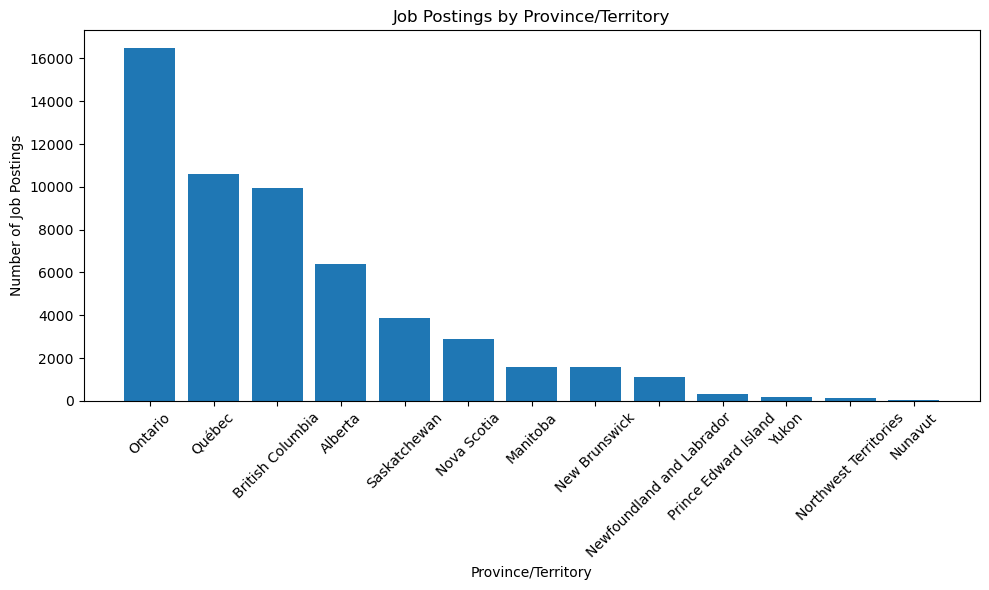

In [30]:
# Visualize job postings distribution by province

plt.figure(figsize=(10, 6))

plt.bar(
    postings_by_province["province"],
    postings_by_province["posting_count"]
)

plt.title(
    "Job Postings by Province/Territory"
)

plt.xlabel(
    "Province/Territory"
)

plt.ylabel(
    "Number of Job Postings"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURES /
    "Job_Postings_by_Province.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

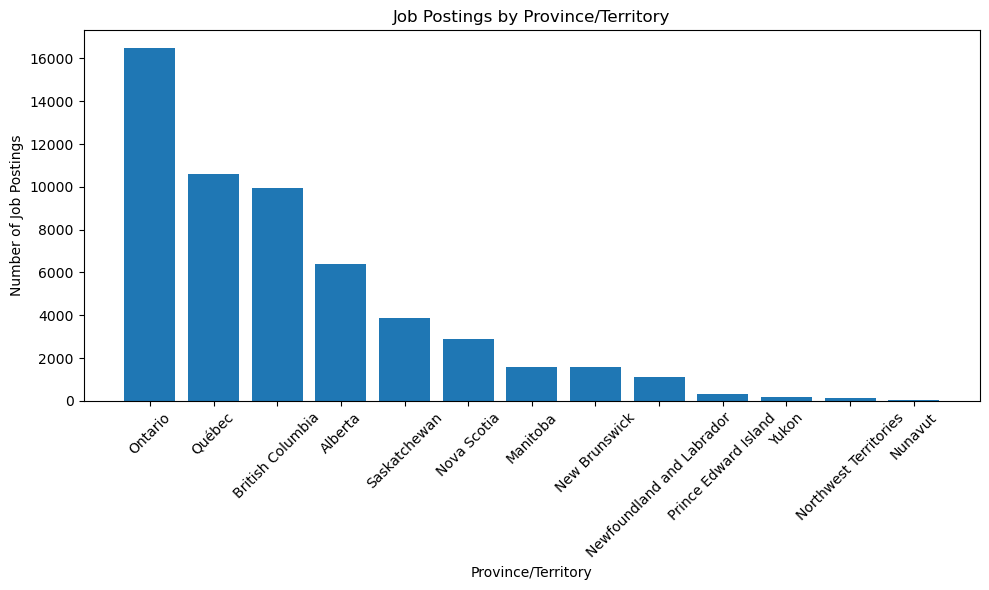

In [41]:
# Create visualization of job postings by province/territory

plt.figure(figsize=(10, 6))

plt.bar(
    postings_by_province["province"],
    postings_by_province["posting_count"]
)

plt.title(
    "Job Postings by Province/Territory"
)

plt.xlabel(
    "Province/Territory"
)

plt.ylabel(
    "Number of Job Postings"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURES /
    "Job_Postings_by_Province.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
# Calculate total advertised vacancies by province/territory

vacancies_by_province = (
    job_bank_clean
    .groupby("province")[
        "vacancy_count"
    ]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

vacancies_by_province.columns = [
    "province",
    "total_vacancies"
]

vacancies_by_province

,province,total_vacancies
0,Ontario,24213
1,Québec,21287
2,British Columbia,16403
3,Alberta,9663
4,Saskatchewan,4588
5,Nova Scotia,4333
6,Manitoba,2715
7,New Brunswick,2288
8,Newfoundland and Labrador,1999
9,Prince Edward Island,1002


In [45]:
# Export total advertised vacancies by province

vacancies_by_province.to_excel(
    TABLES /
    "Vacancies_by_Province.xlsx",
    index=False
)

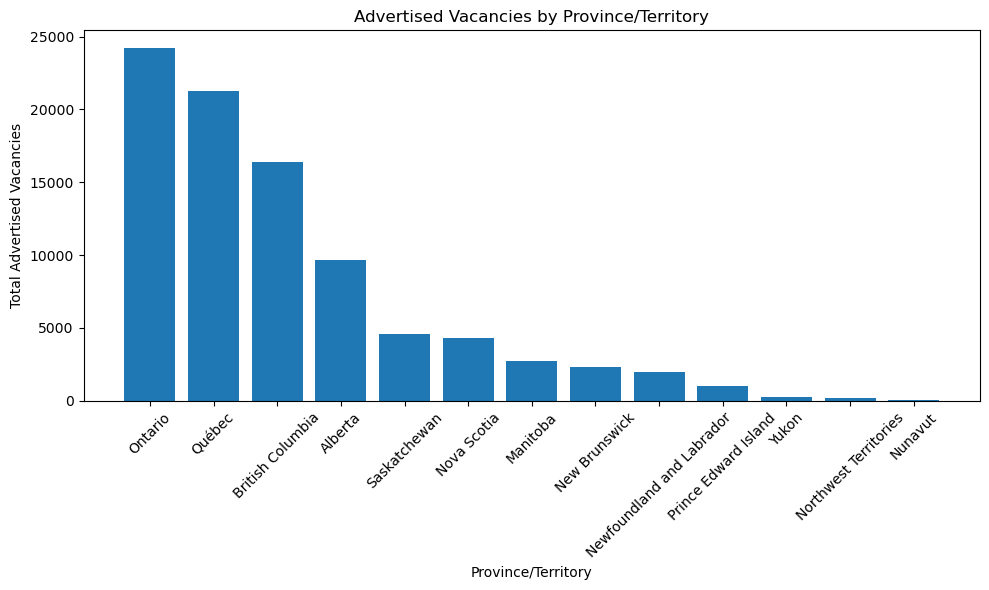

In [47]:
# Create visualization of advertised vacancies by province/territory

plt.figure(figsize=(10, 6))

plt.bar(
    vacancies_by_province["province"],
    vacancies_by_province["total_vacancies"]
)

plt.title(
    "Advertised Vacancies by Province/Territory"
)

plt.xlabel(
    "Province/Territory"
)

plt.ylabel(
    "Total Advertised Vacancies"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURES /
    "Advertised_Vacancies_by_Province.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# Identify top 20 occupations by number of job postings

top_job_titles = (
    job_bank_clean[
        "job_title"
    ]
    .value_counts()
    .head(20)
    .reset_index()
)

top_job_titles.columns = [
    "job_title",
    "posting_count"
]

top_job_titles

,job_title,posting_count
0,cook,1263
1,food service supervisor,750
2,line cook,642
3,administrative assistant,580
4,continuing care assistant,545
5,carpenter,486
6,restaurant manager,465
7,retail sales associate,459
8,"driver, truck",425
9,cashier,410


In [51]:
# Export top 20 job titles by posting count

top_job_titles.to_excel(
    TABLES /
    "Top_20_Job_Titles.xlsx",
    index=False
)

In [53]:
# Identify top 20 occupations by NOC 2021 classification

top_noc_codes = (
    job_bank_clean[
        [
            "noc_2021_code",
            "noc_2021_name"
        ]
    ]
    .value_counts()
    .head(20)
    .reset_index(name="posting_count")
)

top_noc_codes

,noc_2021_code,noc_2021_name,posting_count
0,63200.0,Cooks,2525
1,64100.0,Retail salespersons and visual merchandisers,1876
2,65201.0,"Food counter attendants, kitchen helpers and r...",1640
3,73300.0,Transport truck drivers,1423
4,60030.0,Restaurant and food service managers,1139
5,62020.0,Food service supervisors,1061
6,44100.0,Home child care providers,1050
7,65310.0,Light duty cleaners,1038
8,44101.0,"Home support workers, caregivers and related o...",991
9,62200.0,Chefs,888


In [55]:
# Export top 20 NOC 2021 occupations by posting count

top_noc_codes.to_excel(
    TABLES /
    "Top_20_NOC_Codes.xlsx",
    index=False
)

In [57]:
# Analyze job postings by employment type

employment_distribution = (
    job_bank_clean[
        "employment_type"
    ]
    .value_counts(dropna=False)
    .reset_index()
)

employment_distribution.columns = [
    "employment_type",
    "posting_count"
]

employment_distribution

,employment_type,posting_count
0,Full time,45139
1,Part time,6829
2,NaN,2032
3,Part time leading to full time,1091


In [59]:
# Export employment type distribution summary

employment_distribution.to_excel(
    TABLES /
    "Employment_Type_Distribution.xlsx",
    index=False
)

In [61]:
# Analyze job postings by education requirement

education_distribution = (
    job_bank_clean[
        "education_level"
    ]
    .value_counts(dropna=False)
    .reset_index()
)

education_distribution.columns = [
    "education_level",
    "posting_count"
]

education_distribution

,education_level,posting_count
0,NaN,33112
1,Secondary (high) school graduation certificate,10232
2,"No degree, certificate or diploma",5643
3,College/CEGEP,1323
4,"College, CEGEP or other non-university certifi...",1265
5,Other trades certificate or diploma,1210
6,Bachelor's degree,1206
7,"College, CEGEP or other non-university certifi...",388
8,Registered Apprenticeship certificate,321
9,"Degree in medicine, dentistry, veterinary medi...",171


In [63]:
# Export education requirement distribution summary

education_distribution.to_excel(
    TABLES /
    "Education_Requirement_Distribution.xlsx",
    index=False
)

In [65]:
# Analyze job postings by experience requirement

experience_distribution = (
    job_bank_clean[
        "experience_level"
    ]
    .value_counts(dropna=False)
    .reset_index()
)

experience_distribution.columns = [
    "experience_level",
    "posting_count"
]

experience_distribution

,experience_level,posting_count
0,NaN,33112
1,1 year to less than 2 years,6107
2,No experience,5490
3,2 years to less than 3 years,3493
4,3 years to less than 5 years,2131
5,1 to less than 7 months,1816
6,7 months to less than 1 year,1751
7,5 years or more,1191


In [67]:
# Export experience requirement distribution summary

experience_distribution.to_excel(
    TABLES /
    "Experience_Requirement_Distribution.xlsx",
    index=False
)

## Difference Between Job Postings and Vacancies

A **job posting** represents a single advertisement published by an employer to recruit workers for one or more positions.

A **vacancy** represents the number of available positions advertised within that posting.

A single job posting may contain multiple vacancies. Therefore, vacancy counts provide a more accurate measure of labour demand than posting counts alone, as they capture the estimated number of positions employers are seeking to fill.